In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [ ]:
from boulder_statistics.analysis.quick_calculate_PowerLaw import PowerLawFittingFunction

fit = PowerLawFittingFunction(dp, LAD_min=2)

In [ ]:
class TheoryFit(GenericLikelihoodModel):
    param_names = ["q", "g"]

    def __init__(self, x):
        super().__init__(x)

    def loglikeobs(self, params):
        alphas = self.endog

        fit_params = PowerLawFitParams(
            q = params[0],
            g = params[1]
        )

        print(f"Ran iteration with params {params}")
        return np.log(fit.F_norm(alphas, fit_params))

    @property
    def start_params(self):
        return np.array([1.1, 1.8])
    
mle_model = TheoryFit(fit.cleaned_data.collect()["alpha"].to_numpy()).fit()

Ran iteration with params [1.1 2. ]


C:\Users\Joshu\AppData\Local\Temp\ipykernel_8496\4219585418.py:16: RuntimeWarning: divide by zero encountered in log
  return np.log(fit.F_norm(alphas, fit_params))


Ran iteration with params [1.155 2.   ]
Ran iteration with params [1.1 2.1]
Ran iteration with params [1.155 1.9  ]
Ran iteration with params [1.11375 2.05   ]
Ran iteration with params [1.1275 2.    ]
Ran iteration with params [1.1  2.05]
Ran iteration with params [1.1275 1.95  ]
Ran iteration with params [1.106875 2.025   ]
Ran iteration with params [1.11375 2.     ]
Ran iteration with params [1.1   2.025]
Ran iteration with params [1.11375 1.975  ]
Ran iteration with params [1.1034375 2.0125   ]
Ran iteration with params [1.106875 2.      ]
Ran iteration with params [1.1    2.0125]
Ran iteration with params [1.106875 1.9875  ]
Ran iteration with params [1.10171875 2.00625   ]
Ran iteration with params [1.1034375 2.       ]
Ran iteration with params [1.1     2.00625]
Ran iteration with params [1.1034375 1.99375  ]
Ran iteration with params [1.10085938 2.003125  ]
Ran iteration with params [1.10171875 2.        ]
Ran iteration with params [1.1      2.003125]
Ran iteration with params 

In [ ]:
print(mle_model.summary())
mle_model.model.loglikeobs(mle_model.params).mean()

Ran iteration with params [1.14361328 1.83203125]
                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -6.5634e+05
Model:                      TheoryFit   AIC:                         1.313e+06
Method:            Maximum Likelihood   BIC:                         1.313e+06
Date:                Thu, 25 Jun 2026                                         
Time:                        13:32:59                                         
No. Observations:               85122                                         
Df Residuals:                   85120                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           1.1436      0.004    258.461      0.000       1.135       1.152
pa

np.float64(-7.710633339766244)

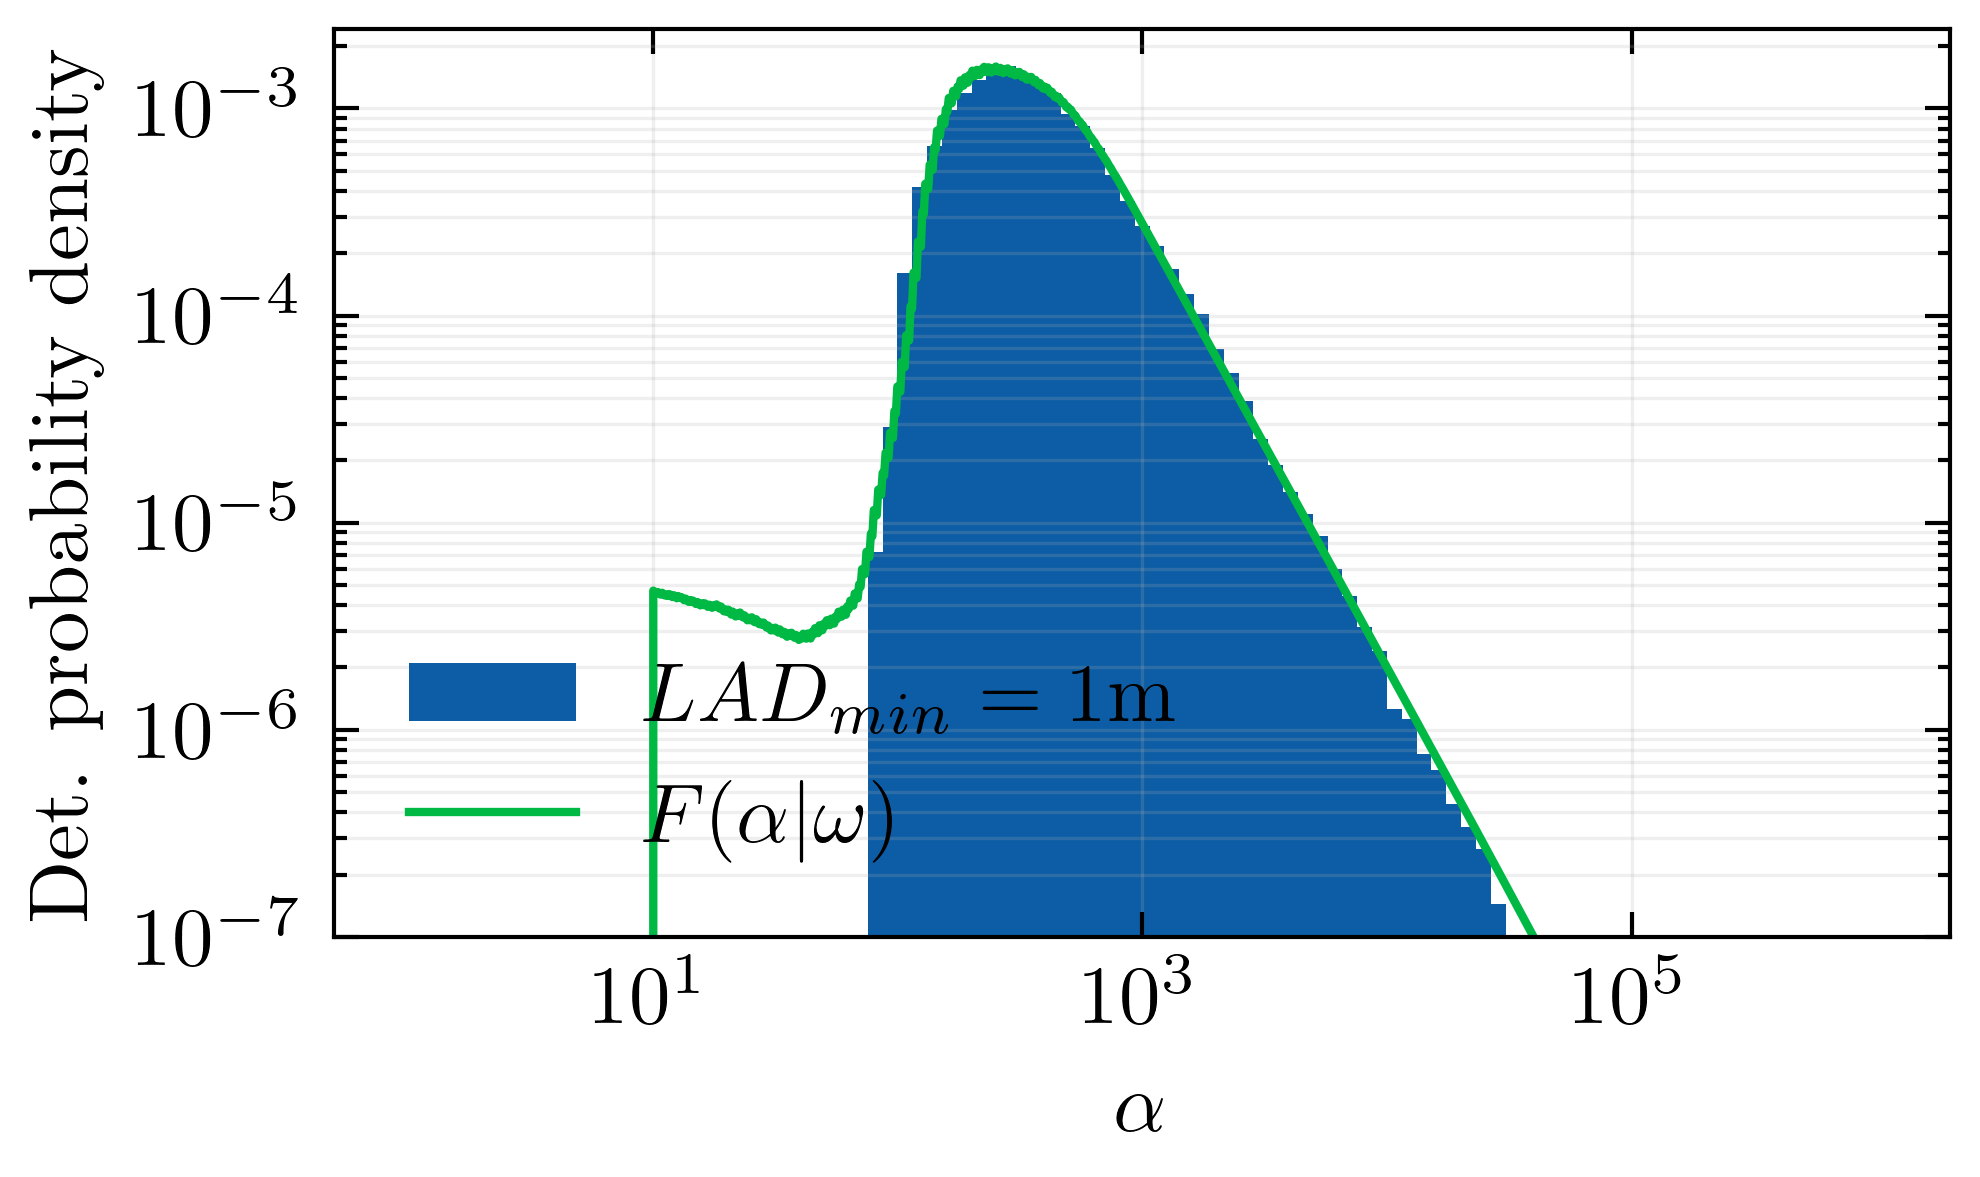

In [ ]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = rf"$LAD_{{min}} = {fit.LAD_min}$m")

fit_params = PowerLawFitParams(*mle_model.params)
plt.plot(alphas, fit.F_norm(alphas, fit_params), label = r"$F(\alpha|\omega)$")

plt.ylim(1e-7, counts.max() * 1.5)
# plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()